# TZ Fornacis paper figures — a playground

Every figure in `tutorial/paper_results/paper_plots/tz_fornacis/` that comes from the joint-fit
results, rebuilt here one cell per figure so the colours, sizes and labels can be edited.

**How to use it**

* `PALETTE` and `STYLE` in the setup cell drive every panel. Change a colour there and re-run
  the figure cells; or edit a single cell directly if you only want to change one plot.
* `SAVE = False` by default, so experimenting never overwrites the committed paper figures.
  Set `SAVE = True` in the setup cell to write `png` + `pdf` to the paper-plots directory.
* Nothing here synthesises a spectrum: the cells read the result pickles and model dumps in
  `tzfor_aemu_out/`, so they run in seconds on a laptop (the spectrum dumps are ~140 MB each,
  so those two cells take a few seconds to load).

The figures, in order: the treatment matrix, the radius–temperature degeneracy, the photometric
constraint on the radius ratio, the eclipse profiles, SPICE's binary against the PHOEBE meshes,
the fitted spectra, and the light curves with residuals.

The science behind them is in `tzfor_teff2_revision.ipynb`, sections 7.3–7.5.

## Setup: paths, palette, helpers

Everything the figure cells share. Edit `PALETTE`/`STYLE` and re-run the cells below.

In [1]:
import pickle, sys, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- where things live -------------------------------------------------------------------
# Three independent locations, because they are not the same directory:
#   SCRIPTS  holds tzfor_constants.py and the fit scripts   (must be on sys.path)
#   SEARCH   holds the pickles and .npz model dumps         (several directories are tried)
#   OUT_DIR  is where figures are written when SAVE is on
# On a laptop all three sit in the repo; on Gadi the results are in /scratch/y89/mj8805/tzfor_joint_out
# while the scripts are in /scratch/y89/mj8805/spice_docsexp/run.
GADI_RUN, GADI_OUT = Path("/scratch/y89/mj8805/spice_docsexp/run"), Path("/scratch/y89/mj8805/tzfor_joint_out")

def _find_scripts(start=Path.cwd()):
    for p in [start, *start.parents, GADI_RUN]:
        if (p / "tzfor_constants.py").exists(): return p
    raise FileNotFoundError("tzfor_constants.py not found; set SCRIPTS by hand")

SCRIPTS = _find_scripts()
SEARCH  = [p for p in (SCRIPTS / "tzfor_aemu_out", GADI_OUT, SCRIPTS) if p.is_dir()]
OUT_DIR = SCRIPTS.parent / "paper_plots" / "tz_fornacis"
SAVE = False                                          # True -> write png + pdf to OUT_DIR

sys.path.insert(0, str(SCRIPTS))
import tzfor_constants as K

def find(name):
    """First existing copy of a result file across SEARCH, or None."""
    for d in SEARCH:
        if (d / name).exists(): return d / name
    return None

def load(name):
    """A result pickle, or None if this machine does not have that run."""
    p = find(name)
    if p is None: print(f"missing: {name} (looked in {', '.join(str(d) for d in SEARCH)})"); return None
    return pickle.load(open(p, "rb"))

def load_npz(name):
    p = find(name)
    if p is None: print(f"missing: {name} (looked in {', '.join(str(d) for d in SEARCH)})"); return None
    return np.load(p, allow_pickle=True)

# ---- the knobs worth playing with -------------------------------------------------------
PALETTE = {
    "data":       "0.35",     # observed photometry / HARPS points
    "model":      "C3",       # the adopted joint-fit model
    "fixed":      "C0",       # fixed (PHOEBE) geometry
    "free":       "C3",       # free geometry
    "delta":      "C1",       # line-strength-map solutions
    "plain":      "C7",       # unmasked solutions
    "masked":     "C0",       # 5% learned mask solutions
    "primary":    "C0",       # the K giant's contribution
    "secondary":  "C1",       # the secondary's contribution
    "residual":   "0.4",
    "literature": "k",        # Andersen et al. (1991)
    "guide":      "0.6",      # degeneracy / constant-quantity guide lines
    "phoebe":     "C0",       # PHOEBE photometric chi2
    "teff":       "C2",
}
STYLE = {
    "ms_point": 4, "ms_marker": 7, "ms_free": 9, "ms_star": 17,
    "lw_model": 1.5, "lw_guide": 1.2, "alpha_grid": 0.3, "font_legend": 8.5,
    "mask_shade": ("C3", 0.12),      # (colour, alpha) for masked pixels
}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "savefig.dpi": 150})

_FALLBACK = ["Teff1", "Teff2", "feh"]          # tzfor_kernel_fit.py stores no parameter names
def names(d): return list(d["pnames"]) if "pnames" in d else _FALLBACK
def val(d, key, default=np.nan):
    nm = names(d); return float(np.asarray(d["theta"])[nm.index(key)]) if key in nm else default
def err(d, key):
    nm = names(d)
    if d.get("jackknife_err") is None or key not in nm: return np.nan
    return float(np.asarray(d["jackknife_err"])[nm.index(key)])

def finish(fig, stem):
    """Show the figure, and write it to OUT_DIR only when SAVE is on."""
    if SAVE:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        for ext in ("png", "pdf"): fig.savefig(OUT_DIR / f"{stem}.{ext}", bbox_inches="tight")
        print("saved", OUT_DIR / f"{stem}.png")
    plt.show()

print(f"scripts: {SCRIPTS}\nresults: {', '.join(str(d) for d in SEARCH)}\nfigures: {OUT_DIR}  (SAVE = {SAVE})")

scripts: /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis
results: /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis/tzfor_aemu_out, /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis
figures: /Users/mjablons/code/spice/tutorial/paper_results/paper_plots/tz_fornacis  (SAVE = False)


## 1. Every joint solution, with its jackknife errors

Teff1 against Teff2 for the whole chain of fits, the sampler posterior means as crosses, and
Andersen's literature values. The free-geometry points are filled, everything else open.

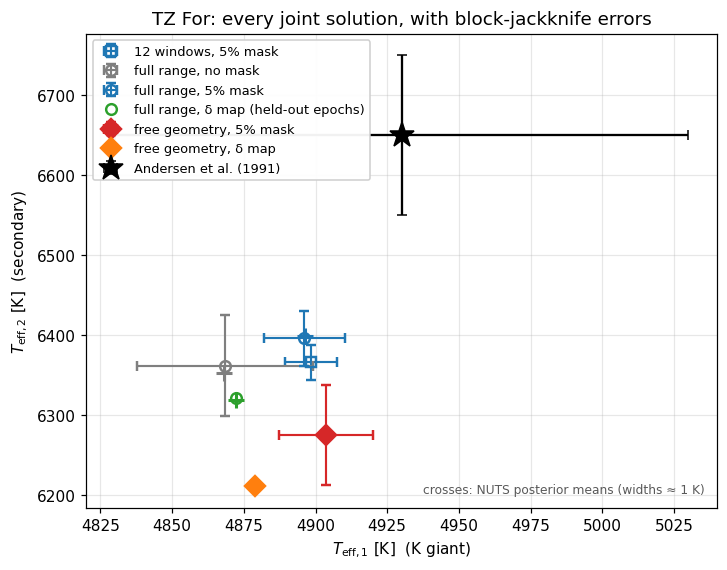

In [2]:
ROWS = [  # file, label, marker, palette key
    ("kernel_fit_result_mask5.pkl",   "12 windows, 5% mask",                 "s", "masked"),
    ("fullrange_pass1_hp.pkl",        "full range, no mask",                 "o", "plain"),
    ("fullrange_maskall_hp.pkl",      "full range, 5% mask",                 "o", "masked"),
    ("fullrange_even_deltaodd.pkl",   "full range, δ map (held-out epochs)", "o", "teff"),
    ("fullrange_maskall_geo.pkl",     "free geometry, 5% mask",              "D", "free"),
    ("fullrange_deltaodd_geo.pkl",    "free geometry, δ map",                "D", "delta"),
]
POSTERIORS = [("nuts_full_pass1.npz", "plain"), ("nuts_full_maskall.npz", "masked"), ("nuts_full_deltaodd.npz", "teff")]

fig, ax = plt.subplots(figsize=(7.4, 5.6))
jk = load("fullrange_maskall_geoJ.pkl")          # the free-geometry errors come from a separate jackknife run
for f, label, marker, ckey in ROWS:
    d = load(f)
    if d is None:
        print("missing:", f); continue
    e1, e2 = (err(jk, "Teff1"), err(jk, "Teff2")) if (f == "fullrange_maskall_geo.pkl" and jk) else (err(d, "Teff1"), err(d, "Teff2"))
    c = PALETTE[ckey]; free = marker == "D"
    ax.errorbar(val(d, "Teff1"), val(d, "Teff2"),
                xerr=None if np.isnan(e1) else e1, yerr=None if np.isnan(e2) else e2,
                fmt=marker, color=c, ms=STYLE["ms_free"] if free else STYLE["ms_marker"],
                mfc=c if free else "none", mew=1.6, capsize=3, lw=1.4, label=label, zorder=3)
for f, ckey in POSTERIORS:
    s = load_npz(f)
    if s is None: continue
    sq = lambda a: a[:, 0] if a.ndim >= 3 and a.shape[1] == 1 else a
    ax.plot(sq(s["Teff1"]).mean(), sq(s["Teff2"]).mean(), "+", color=PALETTE[ckey], ms=11, mew=2, zorder=4)
ax.errorbar(K.PRIMARY_TEFF, K.SECONDARY_TEFF, xerr=100, yerr=100, fmt="*", ms=STYLE["ms_star"],
            color=PALETTE["literature"], capsize=3, label="Andersen et al. (1991)", zorder=5)
ax.set_xlabel("$T_{\\rm eff,1}$ [K]  (K giant)"); ax.set_ylabel("$T_{\\rm eff,2}$ [K]  (secondary)")
ax.set_title("TZ For: every joint solution, with block-jackknife errors")
ax.grid(alpha=STYLE["alpha_grid"]); ax.legend(fontsize=STYLE["font_legend"], loc="upper left", framealpha=0.95)
ax.text(0.98, 0.03, "crosses: NUTS posterior means (widths ≈ 1 K)", transform=ax.transAxes, ha="right", fontsize=8, color="0.35")
finish(fig, "tzfor_teff_treatments")

## 2. The radius–temperature degeneracy

Left: R₂ against Teff2, with the six leave-one-block-out refits that set the error and a line of
constant secondary luminosity. Right: R₁ against R₂ with the line of constant R₁+R₂ that the
eclipse duration fixes — both the fit and the literature values sit on it.

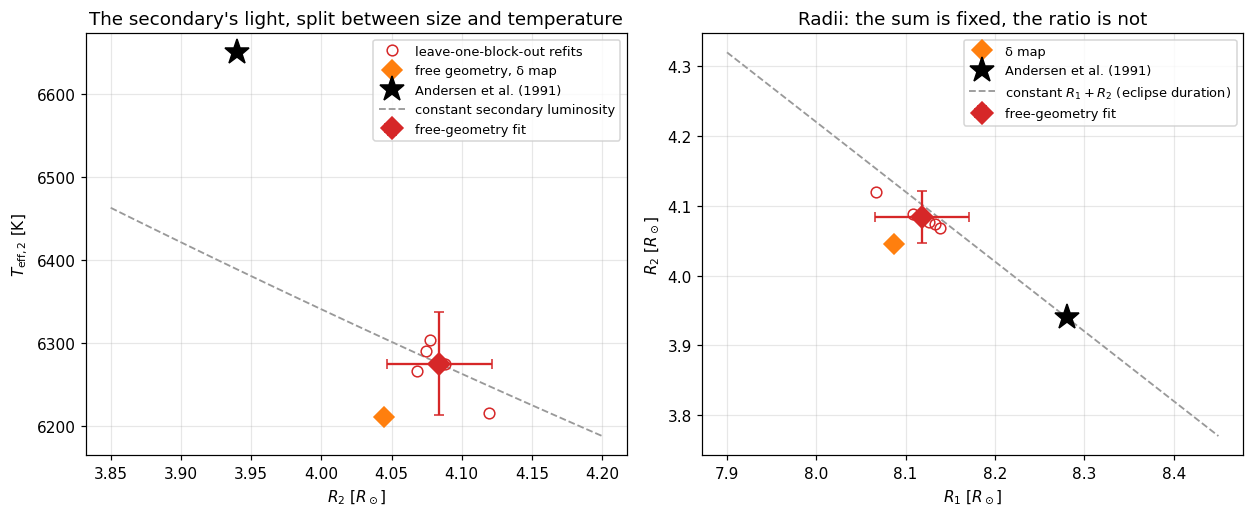

In [3]:
jk, geo, dlt = load("fullrange_maskall_geoJ.pkl"), load("fullrange_maskall_geo.pkl"), load("fullrange_deltaodd_geo.pkl")
if jk is None or geo is None or dlt is None: raise SystemExit("fetch the free-geometry results first")
A = np.asarray(jk["jackknife"]); pn = list(jk["pnames"])
iR1, iR2, iT2 = pn.index("R1"), pn.index("R2"), pn.index("Teff2")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
ax = axes[0]
ax.plot(A[:, iR2], A[:, iT2], "o", color=PALETTE["free"], mfc="none", ms=STYLE["ms_marker"], label="leave-one-block-out refits")
ax.errorbar(val(geo, "R2"), val(geo, "Teff2"), xerr=err(jk, "R2"), yerr=err(jk, "Teff2"),
            fmt="D", color=PALETTE["free"], ms=10, capsize=3, lw=1.5, label="free-geometry fit", zorder=4)
ax.plot(val(dlt, "R2"), val(dlt, "Teff2"), "D", color=PALETTE["delta"], ms=9, label="free geometry, δ map", zorder=4)
ax.plot(K.SECONDARY_RADIUS, K.SECONDARY_TEFF, "*", color=PALETTE["literature"], ms=STYLE["ms_star"], label="Andersen et al. (1991)", zorder=5)
r = np.linspace(3.85, 4.20, 80)
ax.plot(r, val(geo, "Teff2") * np.sqrt(val(geo, "R2") / r), color=PALETTE["guide"], lw=STYLE["lw_guide"], ls="--", zorder=1,
        label="constant secondary luminosity")
ax.set_xlabel("$R_2$ [$R_\\odot$]"); ax.set_ylabel("$T_{\\rm eff,2}$ [K]")
ax.set_title("The secondary's light, split between size and temperature")
ax.grid(alpha=STYLE["alpha_grid"]); ax.legend(fontsize=STYLE["font_legend"])

ax = axes[1]
ax.plot(A[:, iR1], A[:, iR2], "o", color=PALETTE["free"], mfc="none", ms=STYLE["ms_marker"])
ax.errorbar(val(geo, "R1"), val(geo, "R2"), xerr=err(jk, "R1"), yerr=err(jk, "R2"),
            fmt="D", color=PALETTE["free"], ms=10, capsize=3, lw=1.5, label="free-geometry fit", zorder=4)
ax.plot(val(dlt, "R1"), val(dlt, "R2"), "D", color=PALETTE["delta"], ms=9, label="δ map", zorder=4)
ax.plot(K.PRIMARY_RADIUS, K.SECONDARY_RADIUS, "*", color=PALETTE["literature"], ms=STYLE["ms_star"], label="Andersen et al. (1991)", zorder=5)
x = np.linspace(7.9, 8.45, 50)
ax.plot(x, (K.PRIMARY_RADIUS + K.SECONDARY_RADIUS) - x, color=PALETTE["guide"], ls="--", lw=STYLE["lw_guide"], zorder=1,
        label="constant $R_1+R_2$ (eclipse duration)")
ax.set_xlabel("$R_1$ [$R_\\odot$]"); ax.set_ylabel("$R_2$ [$R_\\odot$]")
ax.set_title("Radii: the sum is fixed, the ratio is not")
ax.grid(alpha=STYLE["alpha_grid"]); ax.legend(fontsize=STYLE["font_legend"])
fig.tight_layout(); finish(fig, "tzfor_geometry_degeneracy")

## 3. What the photometry alone says about the radius ratio

PHOEBE's χ² (Roche meshes, ck2004) scanned across R₂/R₁ at fixed R₁+R₂ and fixed inclination,
with Teff2 re-optimised at every ratio. The curve rises monotonically, so the photometry resists
the ratio the spectra want rather than preferring an interior value.

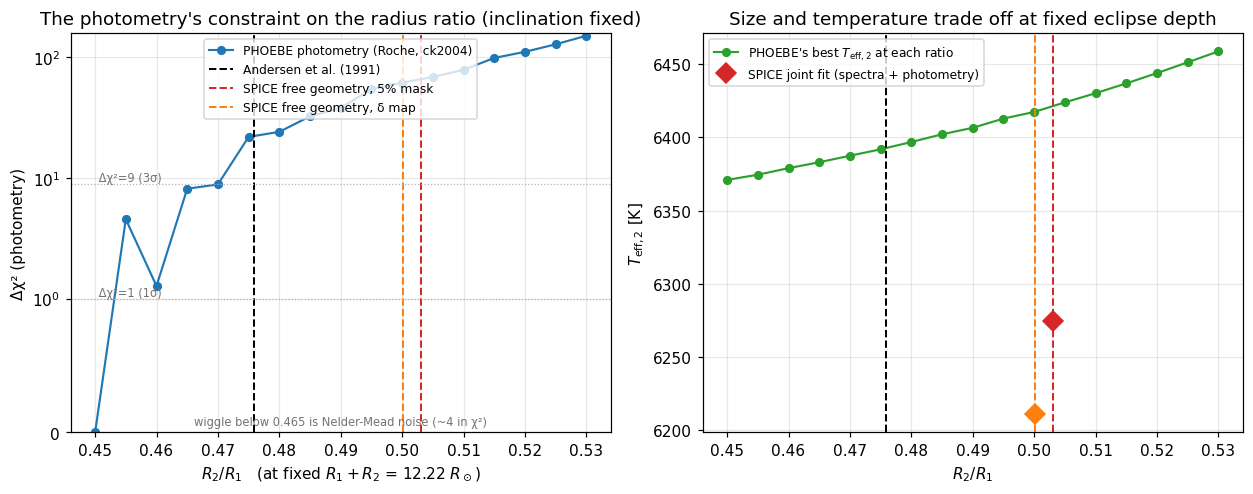

photometry at the SPICE ratio wants Teff2 = 6421 K; the joint fit gives 6275 K


In [4]:
d = load("phoebe_geometry_scan.pkl")   # PHOEBE runs on CPU, so this one is produced locally
if d is None: raise SystemExit
A = np.asarray(d["ratio_scan"], float); N = d["N"]
q, T2, c = A[:, 0], A[:, 3], A[:, 4]
q_lit, q_spice, q_delta = K.SECONDARY_RADIUS / K.PRIMARY_RADIUS, 4.084 / 8.118, 4.045 / 8.087
MARKS = [(q_lit, PALETTE["literature"], "Andersen et al. (1991)"),
         (q_spice, PALETTE["free"], "SPICE free geometry, 5% mask"),
         (q_delta, PALETTE["delta"], "SPICE free geometry, δ map")]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharex=True)
ax = axes[0]
ax.plot(q, c - c.min(), "o-", color=PALETTE["phoebe"], ms=5, lw=1.4, label="PHOEBE photometry (Roche, ck2004)")
for x, col, lab in MARKS: ax.axvline(x, color=col, ls="--", lw=1.3, label=lab)
for lev, txt in ((1.0, "1σ"), (9.0, "3σ")):
    ax.axhline(lev, color="0.7", lw=0.8, ls=":")
    ax.text(q.min(), lev, f" Δχ²={lev:.0f} ({txt})", va="bottom", fontsize=7.5, color="0.45")
ax.set_yscale("symlog", linthresh=1.0); ax.set_ylim(bottom=0)
ax.text(0.5, 0.02, "wiggle below 0.465 is Nelder-Mead noise (~4 in χ²)", transform=ax.transAxes, ha="center", fontsize=7.5, color="0.45")
ax.set_xlabel("$R_2/R_1$   (at fixed $R_1+R_2$ = 12.22 $R_\\odot$)"); ax.set_ylabel("Δχ² (photometry)")
ax.set_title("The photometry's constraint on the radius ratio (inclination fixed)")
ax.grid(alpha=STYLE["alpha_grid"]); ax.legend(fontsize=8, loc="upper center")

ax = axes[1]
ax.plot(q, T2, "o-", color=PALETTE["teff"], ms=5, lw=1.4, label="PHOEBE's best $T_{\\rm eff,2}$ at each ratio")
for x, col, _ in MARKS: ax.axvline(x, color=col, ls="--", lw=1.3)
ax.plot(q_spice, 6275, "D", color=PALETTE["free"], ms=9, label="SPICE joint fit (spectra + photometry)")
ax.plot(q_delta, 6211, "D", color=PALETTE["delta"], ms=9)
ax.set_xlabel("$R_2/R_1$"); ax.set_ylabel("$T_{\\rm eff,2}$ [K]")
ax.set_title("Size and temperature trade off at fixed eclipse depth")
ax.grid(alpha=STYLE["alpha_grid"]); ax.legend(fontsize=8)
fig.tight_layout(); finish(fig, "tzfor_ratio_constraint")

print(f"photometry at the SPICE ratio wants Teff2 = {np.interp(q_spice, q, T2):.0f} K; the joint fit gives 6275 K")

## 4. The eclipses, fixed against free geometry

Both eclipses in both Strömgren bands. Each model is put back on its own out-of-eclipse level,
because the two runs store magnitudes relative to the median over different phase sets.

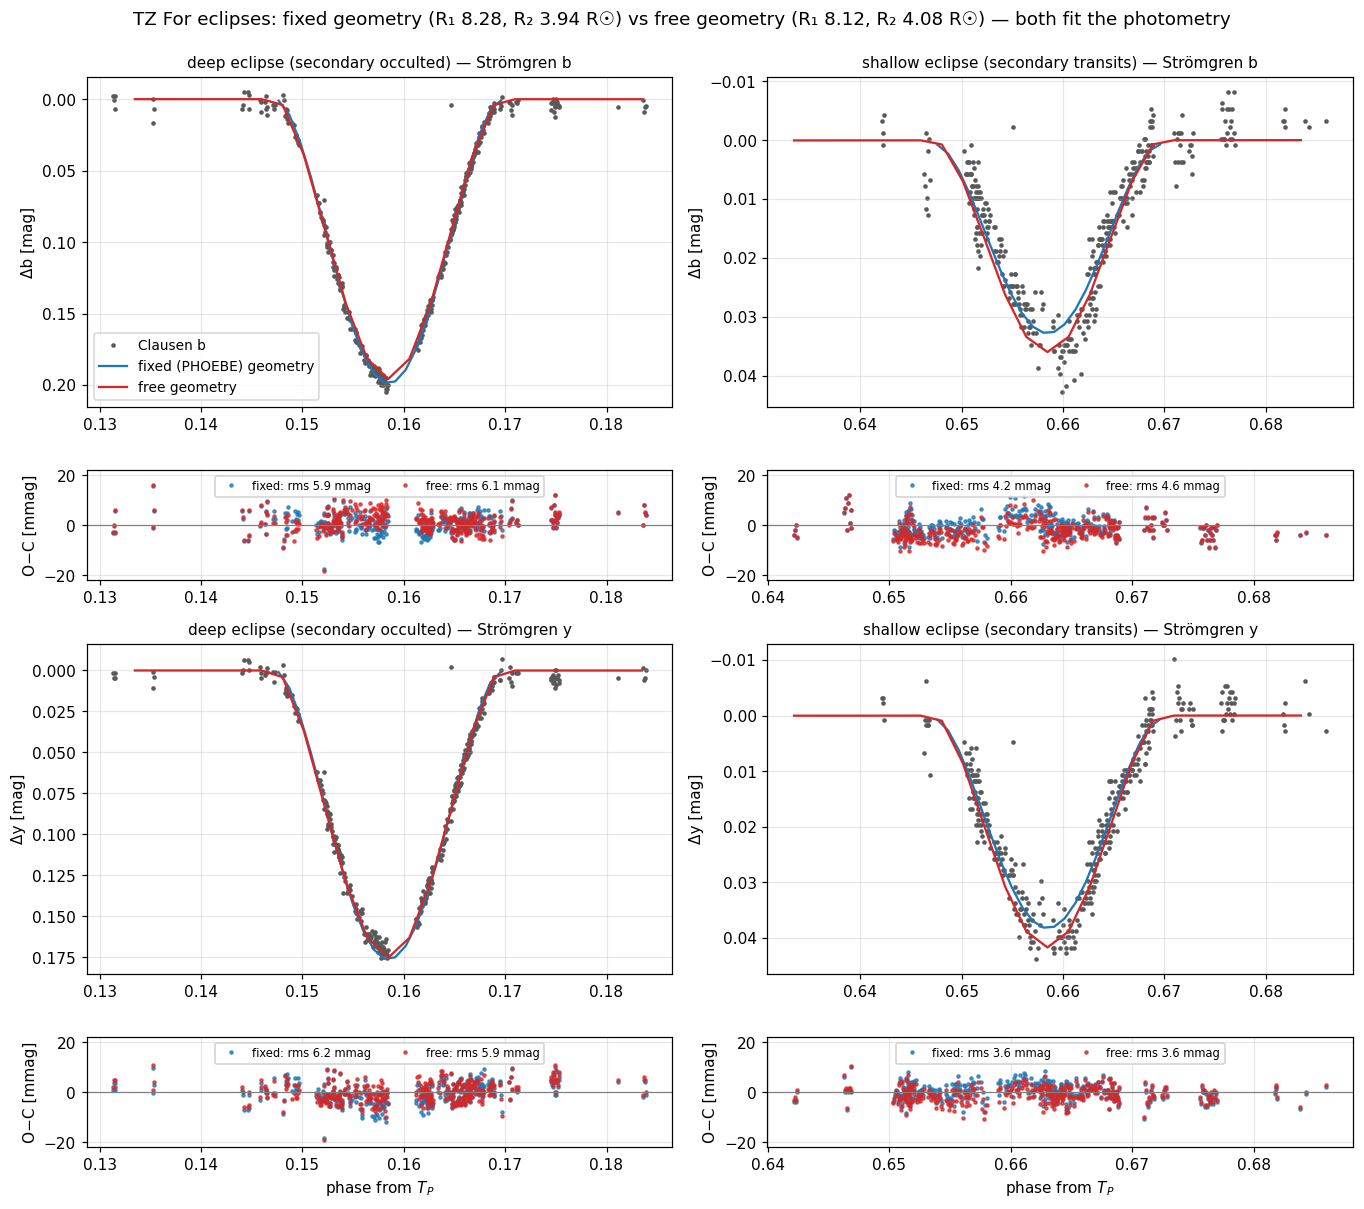

In [5]:
GEO, FIX = load_npz("fr_model_maskall_geo.npz"), load_npz("fr_model_maskall_hp.npz")
if GEO is None or FIX is None: raise SystemExit
dphi = lambda d: float(d["theta"][list(d["pnames"]).index("dphi")])

def curves(d, band):
    lev = float(np.min(d[f"lc_{band}_model_mag"]))              # brightest model point = out of eclipse
    return ((d[f"lc_{band}_model_phase"] + dphi(d)) % 1.0, d[f"lc_{band}_model_mag"] - lev,
            (d[f"lc_{band}_obs_phase"] + dphi(d)) % 1.0, d[f"lc_{band}_obs_mag"] - lev,
            1000.0 * (d[f"lc_{band}_obs_mag"] - d[f"lc_{band}_model_at_obs"]))

near = lambda ph, centre, w=0.028: np.abs(((ph - centre + 0.5) % 1.0) - 0.5) < w
ECLIPSES = [("deep eclipse (secondary occulted)", 0.1585), ("shallow eclipse (secondary transits)", 0.6585)]
MODELS = [(FIX, "fixed", "fixed (PHOEBE) geometry"), (GEO, "free", "free geometry")]

fig, axes = plt.subplots(4, 2, figsize=(12.5, 11), gridspec_kw=dict(height_ratios=[3, 1, 3, 1]))
for r, band in enumerate(("b", "y")):
    for j, (title, centre) in enumerate(ECLIPSES):
        top, bot = axes[2 * r, j], axes[2 * r + 1, j]
        _, _, op, om, _ = curves(FIX, band); sel = near(op, centre)
        top.plot(op[sel], om[sel], ".", color=PALETTE["data"], ms=STYLE["ms_point"], zorder=1, label=f"Clausen {band}")
        for d, ckey, name in MODELS:
            mp, mm, _, _, _ = curves(d, band); s2 = near(mp, centre); o = np.argsort(mp[s2])
            top.plot(mp[s2][o], mm[s2][o], "-", color=PALETTE[ckey], lw=STYLE["lw_model"], zorder=2, label=name)
        top.invert_yaxis(); top.grid(alpha=STYLE["alpha_grid"]); top.set_ylabel(f"Δ{band} [mag]")
        top.set_title(f"{title} — Strömgren {band}", fontsize=10)
        if r == 0 and j == 0: top.legend(fontsize=9, loc="lower left")
        for d, ckey, name in MODELS:
            res = curves(d, band)[4]
            bot.plot(op[sel], res[sel], ".", color=PALETTE[ckey], ms=STYLE["ms_point"], alpha=0.75,
                     label=f"{name.split()[0]}: rms {np.sqrt(np.mean(res[sel] ** 2)):.1f} mmag")
        bot.axhline(0, color="0.5", lw=0.8); bot.grid(alpha=STYLE["alpha_grid"]); bot.set_ylabel("O−C [mmag]")
        bot.set_ylim(-22, 22); bot.legend(fontsize=7.5, ncol=2, loc="upper center", framealpha=0.9)
        if r == 1: bot.set_xlabel("phase from $T_P$")
R1, R2 = (float(GEO["theta"][list(GEO["pnames"]).index(k)]) for k in ("R1", "R2"))
fig.suptitle(f"TZ For eclipses: fixed geometry (R₁ {K.PRIMARY_RADIUS}, R₂ {K.SECONDARY_RADIUS} R☉) "
             f"vs free geometry (R₁ {R1:.2f}, R₂ {R2:.2f} R☉) — both fit the photometry", y=0.995)
fig.tight_layout(); finish(fig, "tzfor_eclipse_zoom")

## 5. SPICE's own binary against the PHOEBE meshes

Same temperatures, same emulator, same kernels: only the geometry engine differs — two icospheres
with SPICE's occlusion, against PHOEBE's Roche meshes.

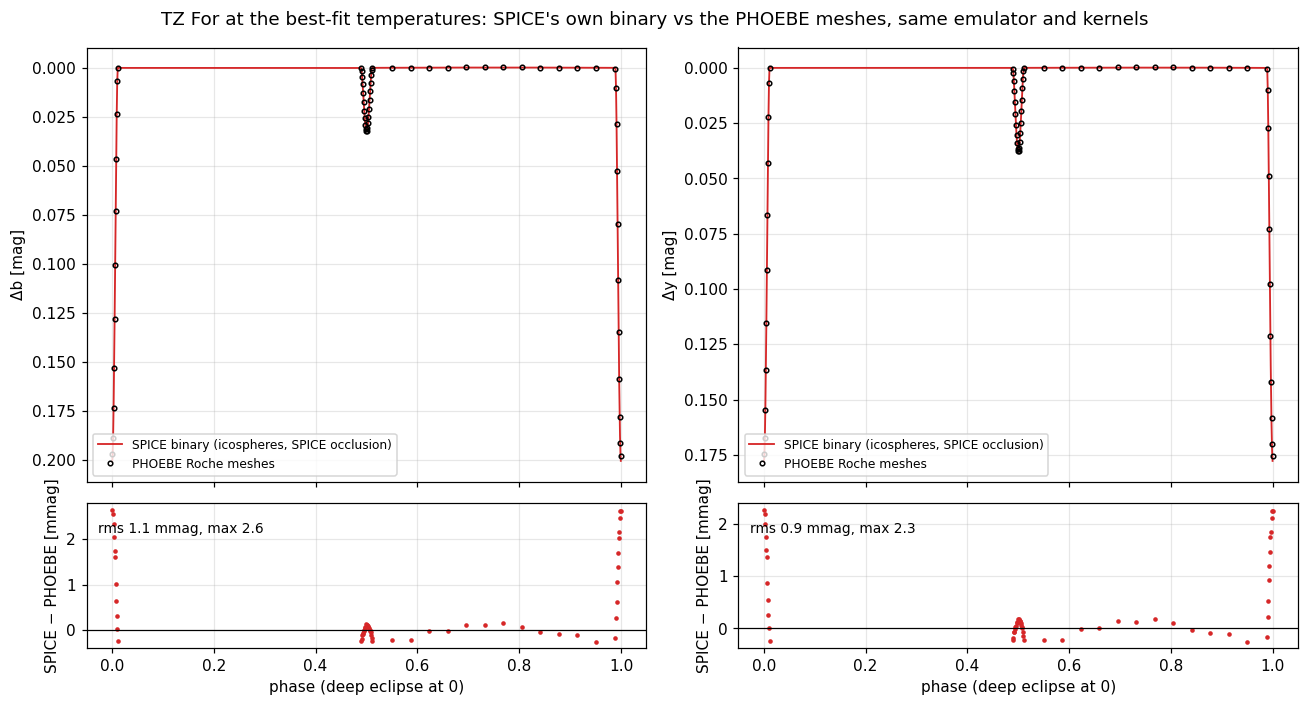

In [6]:
d = load_npz("spice_lc_feasibility.npz")
if d is None: raise SystemExit
php, ps = d["ph_phoebe"], d["ph_spice_1000"]
outside = lambda ph: (np.abs(((ph + 0.5) % 1) - 0.5) > 0.03) & (np.abs(ph - 0.5) > 0.03)

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), gridspec_kw=dict(height_ratios=[3, 1]), sharex="col")
for j, band in enumerate(("b", "y")):
    mp, ms_ = d[f"{band}_phoebe"], d[f"{band}_spice_1000"]
    lp, ls_ = np.median(mp[outside(php)]), np.median(ms_[outside(ps)])
    o = np.argsort(ps); ax = axes[0, j]
    ax.plot(ps[o], (ms_ - ls_)[o], color=PALETTE["free"], lw=1.2, label="SPICE binary (icospheres, SPICE occlusion)")
    ax.plot(php, mp - lp, "o", color=PALETTE["literature"], ms=3, mfc="none", label="PHOEBE Roche meshes")
    ax.invert_yaxis(); ax.set_ylabel(f"Δ{band} [mag]"); ax.grid(alpha=STYLE["alpha_grid"])
    ax.legend(fontsize=8, loc="lower left")
    res = 1000 * (np.interp(php, ps, ms_ - ls_, period=1.0) - (mp - lp)); rax = axes[1, j]
    rax.plot(php, res, ".", color=PALETTE["free"], ms=STYLE["ms_point"])
    rax.axhline(0, color=PALETTE["literature"], lw=0.8)
    rax.text(0.02, 0.8, f"rms {np.sqrt(np.mean(res ** 2)):.1f} mmag, max {np.max(np.abs(res)):.1f}",
             transform=rax.transAxes, fontsize=9)
    rax.set_ylabel("SPICE − PHOEBE [mmag]"); rax.set_xlabel("phase (deep eclipse at 0)"); rax.grid(alpha=STYLE["alpha_grid"])
fig.suptitle("TZ For at the best-fit temperatures: SPICE's own binary vs the PHOEBE meshes, same emulator and kernels")
fig.tight_layout(); finish(fig, "tzfor_spice_vs_phoebe_lc")

## 6. The fitted spectra

Three 40 Å windows at the epoch nearest quadrature: HARPS, the model, each star's contribution and
the residual, with masked pixels shaded. Pick a dump with `DUMP` below — the masked fit, the
line-strength-corrected one, or either with the geometry free.

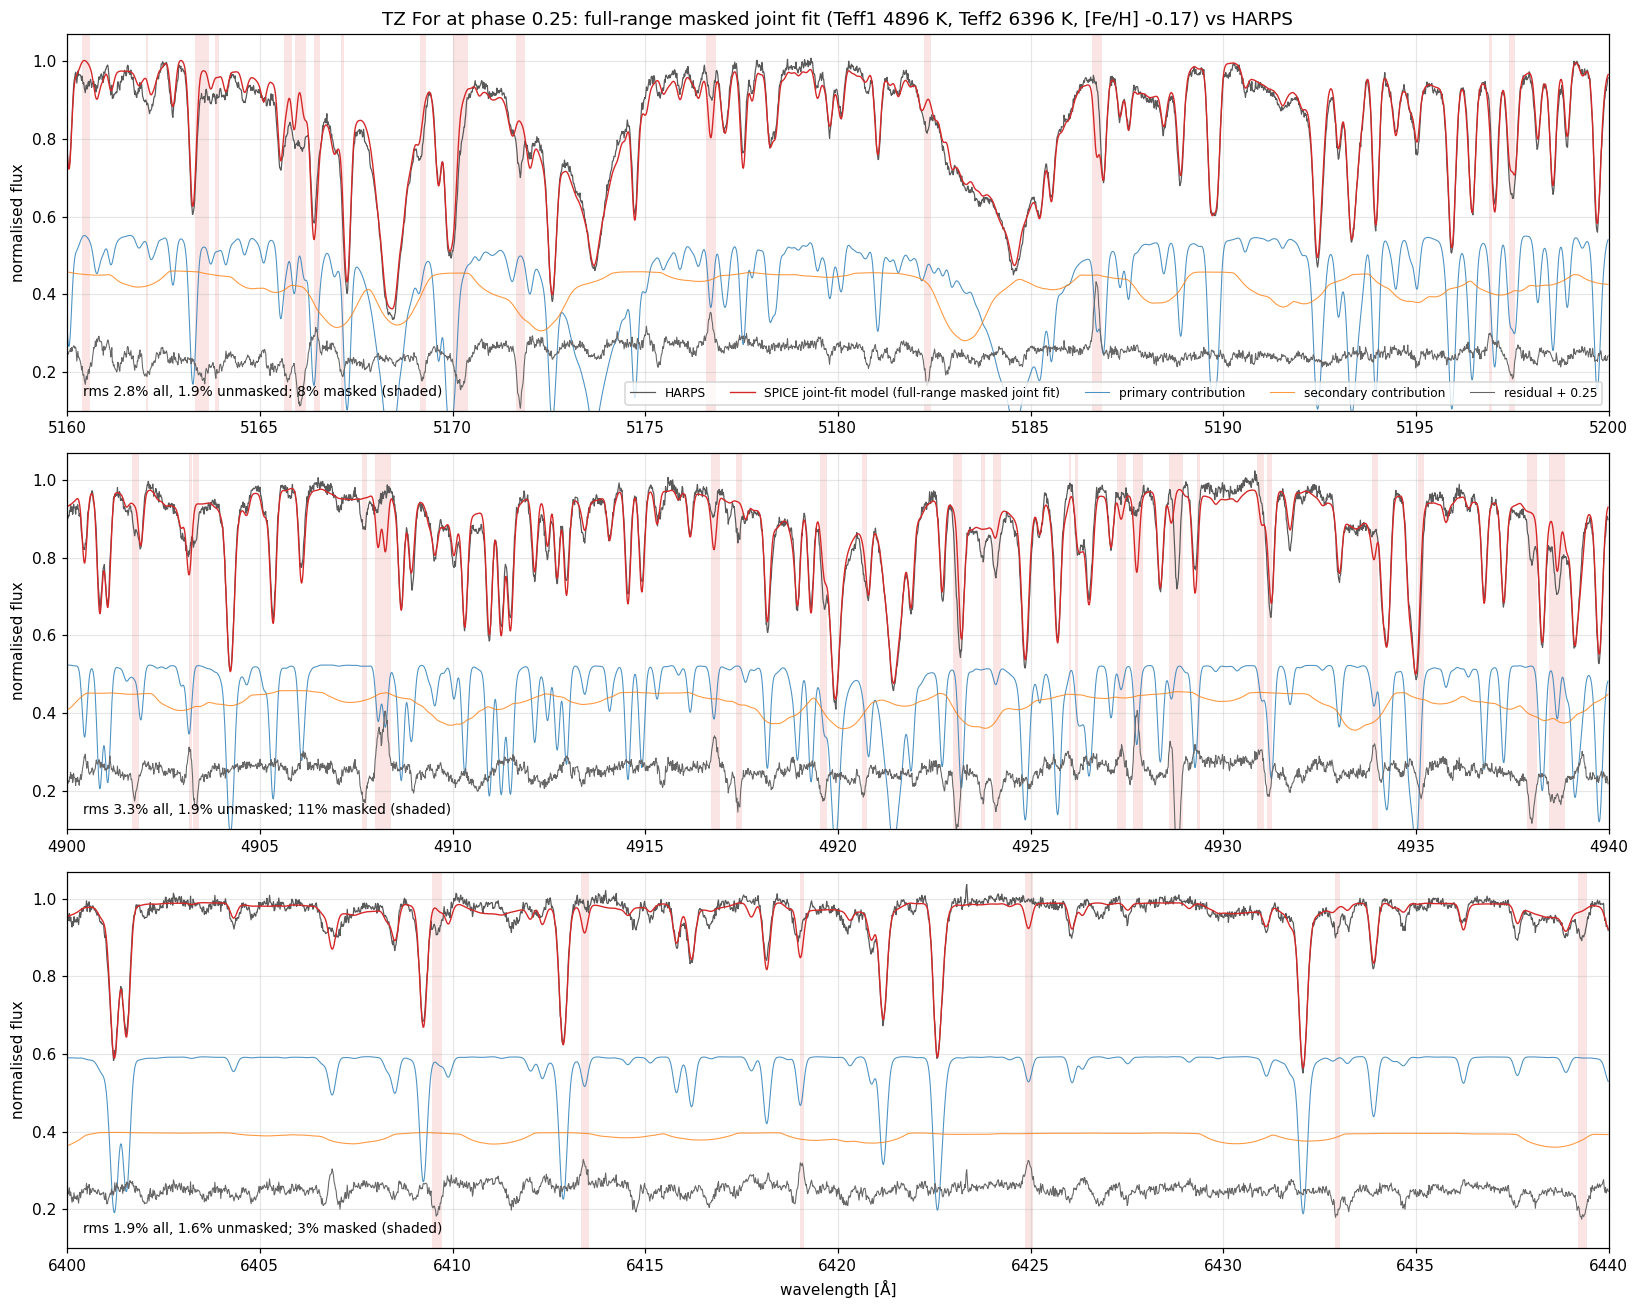

In [7]:
DUMP   = "fr_model_maskall_hp.npz"      # try fr_model_deltaodd.npz, fr_model_maskall_geo.npz, fr_model_deltaodd_geo.npz
LABEL  = "full-range masked joint fit"
PHASE  = 0.25
WINDOWS = [(5160.0, 5200.0), (4900.0, 4940.0), (6400.0, 6440.0)]

d = load_npz(DUMP)
if d is None: raise SystemExit
th, pn = d["theta"], list(d["pnames"])
T1, T2, feh = (float(th[pn.index(k)]) for k in ("Teff1", "Teff2", "feh"))
wl = 10.0 ** d["logwl"]; obs, mod, prim, sec, good = d["obs"], d["model"], d["primary"], d["secondary"], d["good"]
phase = ((d["times"] - K.T_P_HJD) % K.PERIOD_DAYS) / K.PERIOD_DAYS
e = int(np.argmin(np.abs(phase - PHASE)))
usable = np.isfinite(obs[e]); masked = usable & ~good[e]

fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(15, 12))
for ax, (w0, w1) in zip(axes, WINDOWS):
    sel = (wl >= w0) & (wl <= w1); res = obs[e] - mod[e]
    ax.plot(wl[sel], obs[e][sel], color=PALETTE["data"], lw=0.8, label="HARPS")
    ax.plot(wl[sel], mod[e][sel], color=PALETTE["model"], lw=0.9, label=f"SPICE joint-fit model ({LABEL})")
    ax.plot(wl[sel], prim[e][sel], color=PALETTE["primary"], lw=0.7, alpha=0.8, label="primary contribution")
    ax.plot(wl[sel], sec[e][sel], color=PALETTE["secondary"], lw=0.7, alpha=0.8, label="secondary contribution")
    ax.plot(wl[sel], res[sel] + 0.25, color=PALETTE["residual"], lw=0.7, label="residual + 0.25")
    m = masked & sel
    if m.any():
        edges = np.flatnonzero(np.diff(np.concatenate([[0], m.astype(int), [0]])))
        for a, bnd in zip(edges[::2], edges[1::2]):
            ax.axvspan(wl[a], wl[min(bnd, wl.size - 1)], color=STYLE["mask_shade"][0], alpha=STYLE["mask_shade"][1], lw=0)
    r_all = np.sqrt(np.nanmean(res[sel & usable] ** 2)); r_fit = np.sqrt(np.nanmean(res[sel & good[e]] ** 2))
    note = (f"rms {100 * r_all:.1f}% all, {100 * r_fit:.1f}% unmasked; "
            f"{100 * m.sum() / max((sel & usable).sum(), 1):.0f}% masked (shaded)") if masked.any() else f"rms {100 * r_all:.1f}% (no mask)"
    ax.text(0.01, 0.04, note, transform=ax.transAxes, fontsize=9)
    ax.set_xlim(w0, w1); ax.set_ylim(0.1, 1.07); ax.set_ylabel("normalised flux"); ax.grid(alpha=STYLE["alpha_grid"])
axes[0].legend(loc="lower right", ncol=5, fontsize=8); axes[-1].set_xlabel("wavelength [Å]")
axes[0].set_title(f"TZ For at phase {phase[e]:.2f}: {LABEL} (Teff1 {T1:.0f} K, Teff2 {T2:.0f} K, [Fe/H] {feh:+.2f}) vs HARPS")
fig.tight_layout(); finish(fig, "tzfor_spectra_fit_playground")

## 7. The light curves and their residuals

The same dump as the cell above, in Strömgren b and y.

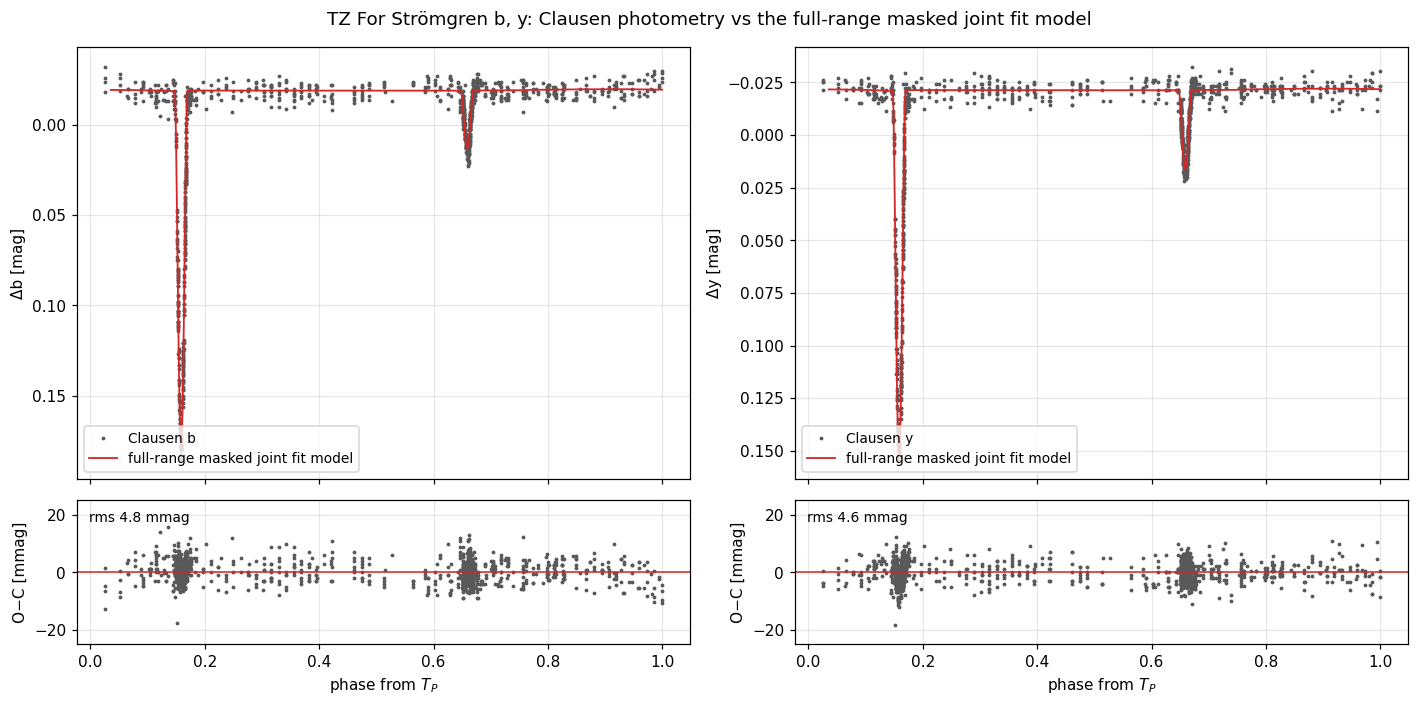

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), gridspec_kw=dict(height_ratios=[3, 1]), sharex="col")
dph = float(th[pn.index("dphi")])
for j, band in enumerate(("b", "y")):
    mp = (d[f"lc_{band}_model_phase"] + dph) % 1.0; mm = d[f"lc_{band}_model_mag"]
    op = (d[f"lc_{band}_obs_phase"] + dph) % 1.0; om = d[f"lc_{band}_obs_mag"]; mo = d[f"lc_{band}_model_at_obs"]
    o = np.argsort(mp); ax = axes[0, j]
    ax.plot(op, om, ".", color=PALETTE["data"], ms=3, label=f"Clausen {band}")
    ax.plot(mp[o], mm[o], color=PALETTE["model"], lw=1.2, label=f"{LABEL} model")
    ax.invert_yaxis(); ax.set_ylabel(f"Δ{band} [mag]"); ax.grid(alpha=STYLE["alpha_grid"])
    ax.legend(loc="lower left", fontsize=9)
    oc = 1000 * (om - mo); rax = axes[1, j]
    rax.plot(op, oc, ".", color=PALETTE["data"], ms=3); rax.axhline(0, color=PALETTE["model"], lw=1)
    rax.set_ylim(-25, 25); rax.text(0.02, 0.85, f"rms {np.sqrt(np.mean(oc ** 2)):.1f} mmag", transform=rax.transAxes, fontsize=9)
    rax.set_xlabel("phase from $T_P$"); rax.set_ylabel("O−C [mmag]"); rax.grid(alpha=STYLE["alpha_grid"])
fig.suptitle(f"TZ For Strömgren b, y: Clausen photometry vs the {LABEL} model")
fig.tight_layout(); finish(fig, "tzfor_lightcurves_fit_playground")

## 8. How the blended spectrum is built

Three phases along the radial-velocity cycle across, and the giant's contribution, the secondary's
contribution and the blend down, all from the fit's own output. The orbit sketch is derived from the
fitted radial velocities rather than an assumed eclipse phase, because the mesh ephemeris and the
photometric one differ by a third of a cycle here.

The whole figure is built in the cells below rather than shelled out to a script, so the star
rendering, the colours and the layout are all editable. `tzfor_line_grid_figure.py` is the same logic
if you would rather run it from the command line.

The default window is the Mg b region, where the fit is at its best: 1.65% residual with nothing
masked, against 2.98% in the 5029-5035 Å window of the original schematic, which contains the spurious
5034.46 Å model line. Swap `WINDOW` to compare the two.

In [9]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ---- how a star is drawn in the orbit sketch ------------------------------------------------
STAR_ANCHORS = [                      # (temperature, RGB) -- interpolated for each star's fitted Teff
    (3500, (0.95, 0.55, 0.25)),
    (4900, (1.00, 0.78, 0.45)),
    (6300, (1.00, 0.95, 0.85)),
    (8000, (0.80, 0.87, 1.00)),
]
LIMB_U   = 0.6        # limb darkening of the drawn disc: 0 = flat, 1 = dark edge
SHADOW   = 0.12       # how dark the limb gets (fraction of the surface colour)
DISC_RES = 160        # pixels across a drawn disc

def star_colour(teff, anchors=STAR_ANCHORS):
    t = float(np.clip(teff, anchors[0][0], anchors[-1][0]))
    for (t0, c0), (t1, c1) in zip(anchors, anchors[1:]):
        if t0 <= t <= t1:
            f = (t - t0) / (t1 - t0)
            return tuple(a + f * (b - a) for a, b in zip(c0, c1))
    return anchors[-1][1]

def draw_star(ax, x, y, radius, teff, zorder=2):
    """A limb-darkened disc of radius `radius` centred on (x, y), in data units."""
    g = np.linspace(-1, 1, DISC_RES); X, Y = np.meshgrid(g, g); r2 = X ** 2 + Y ** 2
    mu = np.sqrt(np.clip(1 - r2, 0, 1))
    img = np.where(r2 <= 1, 1 - LIMB_U * (1 - mu), np.nan)
    base = star_colour(teff)
    cmap = LinearSegmentedColormap.from_list("star", [tuple(SHADOW * c for c in base), base])
    ax.imshow(img, extent=(x - radius, x + radius, y - radius, y + radius), origin="lower",
              cmap=cmap, norm=Normalize(0.0, 1.0), zorder=zorder, interpolation="bilinear")

# ---- the orbit, solved from the fitted radial velocities ------------------------------------
def orbit_from_rvs(phase, rv):
    """Circular-orbit angle theta2(phase) for the secondary, from RV = gamma + K cos(2 pi (phase - phase_max)).

    Returns (theta2, gamma, K1, phase_of_maximum). Sky projection for star 2 relative to the
    barycentre is then x = a2 cos(theta), y = a2 cos(i) sin(theta), depth z = a2 sin(i) sin(theta),
    with the observer at +z; star 1 sits opposite. Solving for the orbit this way rather than
    assuming an eclipse phase matters here: the mesh and photometric ephemerides differ by ~0.34
    in phase, which the joint fit absorbs into dphi.
    """
    M = np.column_stack([np.ones_like(phase), np.cos(2 * np.pi * phase), np.sin(2 * np.pi * phase)])
    c = np.linalg.lstsq(M, rv[0], rcond=None)[0]
    ph_max = float(np.arctan2(c[2], c[1]) / (2 * np.pi)) % 1.0
    resid = float(np.std(rv[0] - M @ c))
    return (lambda p_: 2 * np.pi * (p_ - ph_max) + np.pi), float(c[0]), float(np.hypot(c[1], c[2])), ph_max, resid

print("star rendering and orbit helpers defined")

star rendering and orbit helpers defined


RV curve: gamma +18.42, K1 38.91 km/s, residual 0.000 km/s


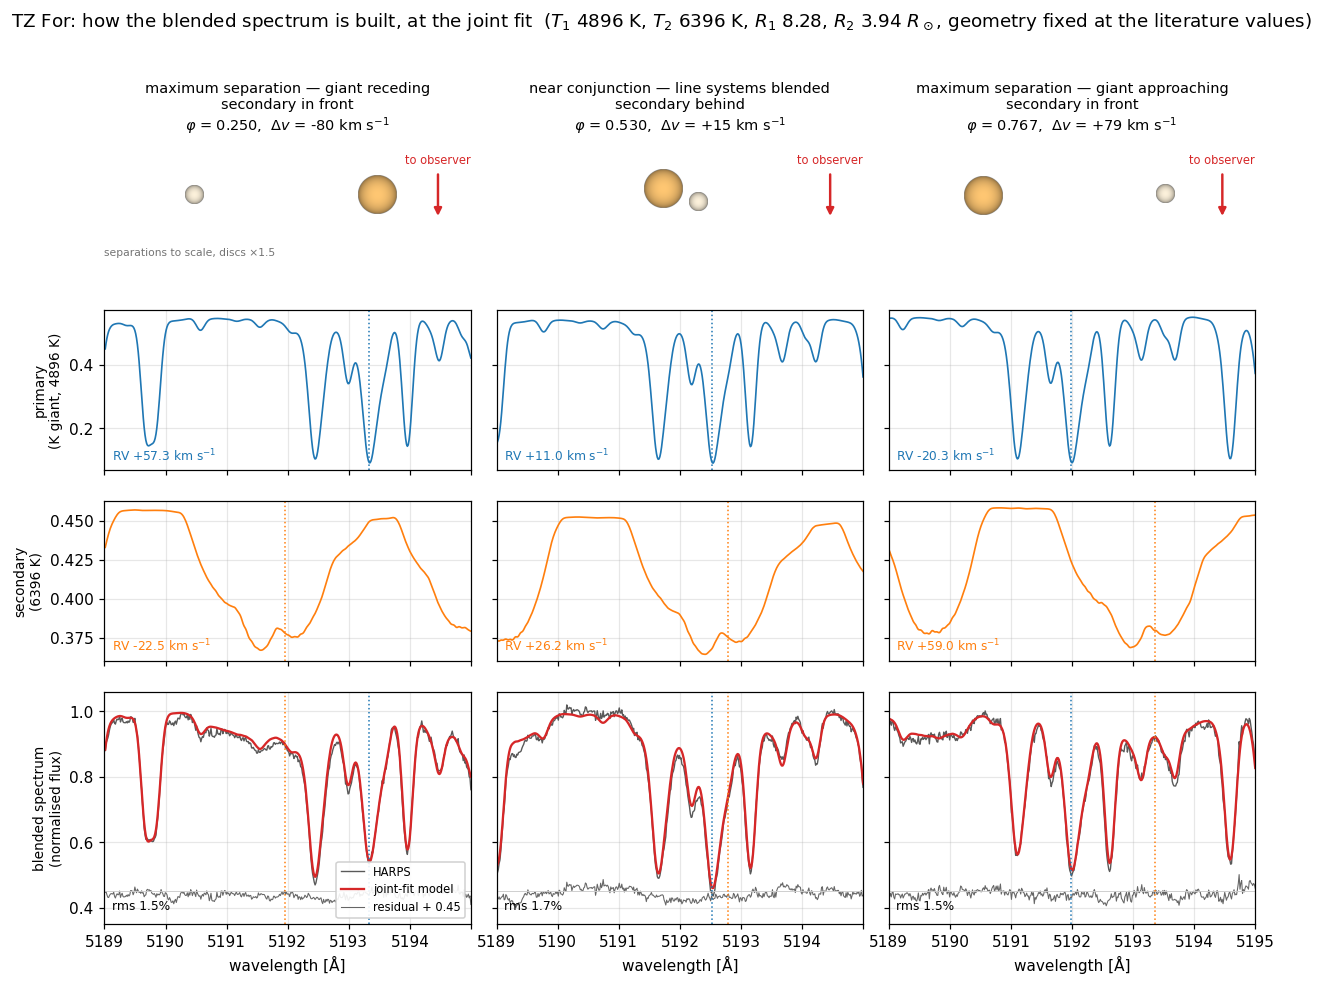

In [10]:
# ---- what to draw ---------------------------------------------------------------------------
WINDOW  = (5189.0, 5195.0)     # Mg b region, the cleanest in the range; try (5029.0, 5035.0)
MARK    = 5192.34              # rest wavelength marked in each component's frame
DUMP    = "fr_model_maskall_hp.npz"   # or fr_model_deltaodd.npz / fr_model_maskall_geo.npz
EXAGGERATE = 1.5               # discs drawn this much larger than scale (capped so they never fake a contact)
RESID_OFFSET = 0.45            # where the residual trace sits in the bottom row
STEM = "tzfor_line_grid_playground"

d = load_npz(DUMP)
if d is None:
    raise SystemExit
th, pn = d["theta"], list(d["pnames"])
getp = lambda k, dflt=np.nan: float(th[pn.index(k)]) if k in pn else dflt
T1, T2 = getp("Teff1"), getp("Teff2")
R1, R2 = getp("R1", K.PRIMARY_RADIUS), getp("R2", K.SECONDARY_RADIUS)
incl   = getp("incl", K.INCL_DEG)
wl  = 10.0 ** d["logwl"]; rv = d["rv"]
phase = ((d["times"] - K.T_P_HJD) % K.PERIOD_DAYS) / K.PERIOD_DAYS
sep = rv[1] - rv[0]
C_KMS = 299792.458

theta2, gamma, K1, ph_max, rv_resid = orbit_from_rvs(phase, rv)
print(f"RV curve: gamma {gamma:+.2f}, K1 {K1:.2f} km/s, residual {rv_resid:.3f} km/s")

# three phases: the two extremes of the RV cycle and the blended configuration between them
EPOCHS = [int(np.argmin(sep)), int(np.argmin(np.abs(sep))), int(np.argmax(sep))]
def title_for(e):
    front = np.sin(theta2(phase[e])) > 0
    where = "secondary in front" if front else "secondary behind"
    if abs(sep[e]) < 0.4 * (K1 + K1):
        return f"near conjunction — line systems blended\n{where}"
    return ("maximum separation — giant receding" if sep[e] < 0 else "maximum separation — giant approaching") + f"\n{where}"

# semi-major axis from Kepler's third law with the dynamical masses
G, Msun, yr, Rsun = 6.67430e-11, 1.98847e30, 3.15576e7, 6.957e8
a = (G * (K.PRIMARY_MASS + K.SECONDARY_MASS) * Msun * (K.PERIOD_YR * yr) ** 2 / (4 * np.pi ** 2)) ** (1 / 3) / Rsun
qm = K.SECONDARY_MASS / K.PRIMARY_MASS
sky_sep = lambda p_: a * np.hypot(np.cos(theta2(p_)), np.cos(np.radians(incl)) * np.sin(theta2(p_)))
EX = EXAGGERATE
closest = min(sky_sep(phase[e]) for e in EPOCHS)
if EX * (R1 + R2) > closest:                      # never let magnified discs fake an eclipse
    EX = max(1.0, 0.95 * closest / (R1 + R2))
    print(f"disc exaggeration capped at {EX:.2f} (closest projected separation {closest:.0f} R_sun)")

# ---- the figure -----------------------------------------------------------------------------
w0, w1 = WINDOW; sel = (wl >= w0) & (wl <= w1)
fig = plt.figure(figsize=(13.5, 9.6))
gs = fig.add_gridspec(4, 3, height_ratios=[1.05, 1.0, 1.0, 1.45], hspace=0.17, wspace=0.07)

for col, e in enumerate(EPOCHS):
    ph = phase[e]
    # orbit sketch
    ax = fig.add_subplot(gs[0, col]); ax.set_aspect("equal"); ax.axis("off")
    th2 = theta2(ph); ci = np.cos(np.radians(incl))
    a2, a1 = a / (1 + qm), a * qm / (1 + qm)
    stars = [(-a1 * np.cos(th2), -a1 * ci * np.sin(th2), EX * R1, T1, -np.sin(th2)),
             ( a2 * np.cos(th2),  a2 * ci * np.sin(th2), EX * R2, T2,  np.sin(th2))]
    for x, y, r, t, z in sorted(stars, key=lambda s_: s_[4]):     # far star first
        draw_star(ax, x, y, r, t, zorder=2 + (z > 0))
    ax.annotate("", xy=(a * 0.82, -a * 0.13), xytext=(a * 0.82, a * 0.13),
                arrowprops=dict(arrowstyle="-|>", color=PALETTE["model"], lw=1.6))
    ax.text(a * 0.82, a * 0.17, "to observer", color=PALETTE["model"], ha="center", fontsize=7.5)
    ax.set_xlim(-a, a); ax.set_ylim(-a * 0.32, a * 0.32)
    ax.set_title(f"{title_for(e)}\n$\\varphi$ = {ph:.3f},  $\\Delta v$ = {sep[e]:+.0f} km s$^{{-1}}$", fontsize=9.5, pad=4)
    if col == 0:
        ax.text(0.0, -0.02, f"separations to scale, discs ×{EX:g}", transform=ax.transAxes, fontsize=7, color="0.45")

    # the two contributions
    for r, (key, label, ckey) in enumerate([("primary", f"primary (K giant, {T1:.0f} K)", "primary"),
                                            ("secondary", f"secondary ({T2:.0f} K)", "secondary")]):
        ax = fig.add_subplot(gs[1 + r, col]); v = rv[r, e]
        ax.plot(wl[sel], d[key][e][sel], color=PALETTE[ckey], lw=1.1)
        ax.axvline(MARK * (1 + v / C_KMS), color=PALETTE[ckey], ls=":", lw=1.0)
        ax.set_xlim(w0 + (1e-6 if col else 0), w1); ax.grid(alpha=STYLE["alpha_grid"])
        ax.tick_params(labelbottom=False)
        if col == 0: ax.set_ylabel(label.replace(" (", "\n("), fontsize=9)
        else: ax.tick_params(labelleft=False)
        ax.text(0.02, 0.06, f"RV {v:+.1f} km s$^{{-1}}$", transform=ax.transAxes, fontsize=8, color=PALETTE[ckey])

    # the blend against HARPS
    ax = fig.add_subplot(gs[3, col])
    obs = np.where(np.isfinite(d["obs"][e]), d["obs"][e], np.nan)
    ax.plot(wl[sel], obs[sel], color=PALETTE["data"], lw=0.9, label="HARPS")
    ax.plot(wl[sel], d["model"][e][sel], color=PALETTE["model"], lw=STYLE["lw_model"], label="joint-fit model")
    ax.plot(wl[sel], obs[sel] - d["model"][e][sel] + RESID_OFFSET, color=PALETTE["residual"], lw=0.7,
            label=f"residual + {RESID_OFFSET}")
    ax.axhline(RESID_OFFSET, color="0.8", lw=0.6)
    for r_ in (0, 1):
        ax.axvline(MARK * (1 + rv[r_, e] / C_KMS), color=PALETTE["primary" if r_ == 0 else "secondary"], ls=":", lw=1.0)
    ax.set_xlim(w0 + (1e-6 if col else 0), w1); ax.set_ylim(0.35, 1.06); ax.grid(alpha=STYLE["alpha_grid"])
    ax.set_xticks(np.arange(np.ceil(w0), np.floor(w1) + 0.1, 1.0)); ax.set_xlabel("wavelength [Å]")
    if col < 2:                                   # the last label of one column collides with the first of the next
        ax.get_xticklabels()[-1].set_visible(False)
    g = d["good"][e] & sel
    ax.text(0.02, 0.06, f"rms {100 * np.sqrt(np.nanmean((obs[g] - d['model'][e][g]) ** 2)):.1f}%",
            transform=ax.transAxes, fontsize=8)
    if col == 0:
        ax.set_ylabel("blended spectrum\n(normalised flux)", fontsize=9)
        ax.legend(fontsize=7.5, loc="lower right", framealpha=0.9)
    else:
        ax.tick_params(labelleft=False)

# shared y limits down each of the two contribution rows
axes = fig.get_axes()
for r in (1, 2):
    row = [axes[k] for k in range(len(axes)) if k % 4 == r]
    lo = min(ax_.get_ylim()[0] for ax_ in row); hi = max(ax_.get_ylim()[1] for ax_ in row)
    for ax_ in row: ax_.set_ylim(lo, hi)

geo_note = "geometry free" if "R1" in pn else "geometry fixed at the literature values"
fig.suptitle(f"TZ For: how the blended spectrum is built, at the joint fit  "
             f"($T_1$ {T1:.0f} K, $T_2$ {T2:.0f} K, $R_1$ {R1:.2f}, $R_2$ {R2:.2f} $R_\\odot$, {geo_note})",
             y=0.975, fontsize=12)
finish(fig, STEM)